In [1]:
import xgboost as xgb

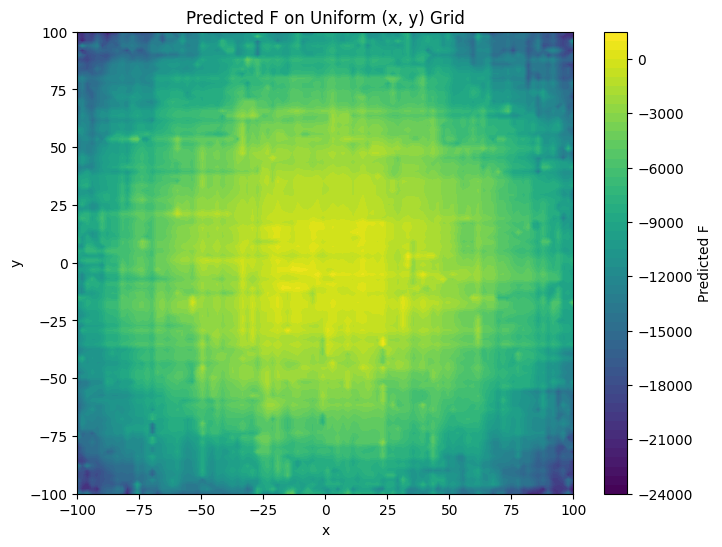

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データ読込（ヘッダー行をスキップ）
df = pd.read_csv("../data/sphere_sampled_benchmark_xy_F.csv", header=0)

# 特徴量と目的変数
X = df[["x", "y"]].values.astype(float)
y = df["F"].values.astype(float)

# モデル構築
reg = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1)
reg.fit(X, y)

# --- 均一なデータ生成 ---

# x, y の範囲決定
x_min, x_max = df["x"].min(), df["x"].max()
y_min, y_max = df["y"].min(), df["y"].max()

# 均一格子点を生成
n_grid = 100
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, n_grid),
    np.linspace(y_min, y_max, n_grid)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 予測
F_pred = reg.predict(grid_points)
F_pred_grid = F_pred.reshape(xx.shape)

# 描画
plt.figure(figsize=(8,6))
contour = plt.contourf(xx, yy, F_pred_grid, 50, cmap="viridis")
plt.colorbar(contour, label='Predicted F')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicted F on Uniform (x, y) Grid")
plt.show()

In [3]:
import random

In [ ]:
# grid_points と F_pred から df_uniform を作成
df_uniform = pd.DataFrame(grid_points, columns=['x', 'y'])
df_uniform['F_pred'] = F_pred
display(df_uniform.head(3))
display(df_uniform.tail(3))
display(df_uniform.shape)

df_uniform.to_csv("../data/sphere_pred_benchmark_xy_F.csv", index=False)
    

,x,y,F_pred
0,-100.000000,-100.0,-12813.666992
1,-97.979798,-100.0,-15103.548828
2,-95.959596,-100.0,-13283.167969


,x,y,F_pred
9997,95.959596,100.0,-16431.986328
9998,97.979798,100.0,-20221.658203
9999,100.000000,100.0,-18778.556641


(10000, 3)